<a href="https://colab.research.google.com/github/KDT-final-project-team4/Multi-Armed-Bandit/blob/main/MAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import numpy as np

In [ ]:
n_arms = 5      # 머신 갯수
n_trials = 10000    # 시도 횟수
true_probs = [0.2, 0.3, 0.4, 0.35, 0.15]  # 각 머신의 실제 성공 확률

In [ ]:
def get_reward(prob):
    return 1 if random.random() < prob else 0

In [ ]:
# Random 전략
def random_bandit(time=1000):
    selected_counts = np.zeros(n_arms)
    total_reward = 0
    cumulative_rewards = []

    for i in range(time):
        chosen_arm = random.randint(0, n_arms-1)
        selected_counts[chosen_arm] += 1

        if get_reward(true_probs[chosen_arm]) == 1:
            total_reward += 1

        cumulative_rewards.append(total_reward)

    return selected_counts, total_reward, cumulative_rewards

In [ ]:
# Greedy 전략
def greedy_bandit(time=1000, exploration_steps=20):
    selected_counts = np.zeros(n_arms)
    q_values = np.zeros(n_arms)
    total_reward = 0
    cumulative_rewards = []

    for i in range(time):
        if i < exploration_steps:
            chosen_arm = i % n_arms
        else:
            chosen_arm = np.random.choice(np.where(q_values == q_values.max())[0])

        reward = get_reward(true_probs[chosen_arm])

        selected_counts[chosen_arm] += 1
        total_reward += reward

        q_values[chosen_arm] += (reward - q_values[chosen_arm]) / selected_counts[chosen_arm]

        cumulative_rewards.append(total_reward)

    return selected_counts, total_reward, cumulative_rewards

In [ ]:
# ε-Greedy 전략
def epsilon_greedy_bandit(time=1000, epsilon=0.1):
    selected_counts = np.zeros(n_arms)
    q_values = np.zeros(n_arms)
    total_reward = 0
    cumulative_rewards = []

    for i in range(time):
        if random.random() < epsilon:
            chosen_arm = random.randint(0, n_arms - 1)
        else:
            chosen_arm = np.random.choice(np.where(q_values == q_values.max())[0])

        reward = get_reward(true_probs[chosen_arm])

        selected_counts[chosen_arm] += 1
        total_reward += reward
        q_values[chosen_arm] += (reward - q_values[chosen_arm]) / selected_counts[chosen_arm]

        cumulative_rewards.append(total_reward)

    return selected_counts, total_reward, cumulative_rewards


### 머신별 선택 비율

In [ ]:
random_counts, random_total, random_history = random_bandit(n_trials)
greedy_counts, greedy_total, greedy_history = greedy_bandit(n_trials, 20)
egreedy_counts, egreedy_total, egreedy_history = epsilon_greedy_bandit(n_trials, 0.1)

print(f"1. Random: 총 보상 {random_total}, 선택 횟수 {random_counts}")
print(f"2. Greedy(20): 총 보상 {greedy_total}, 선택 횟수 {greedy_counts}")
print(f"3. ε-Greedy: 총 보상 {egreedy_total}, 선택 횟수 {egreedy_counts}")

1. Random: 총 보상 2808, 선택 횟수 [1981. 2054. 1992. 1989. 1984.]
2. Greedy(20): 총 보상 3001, 선택 횟수 [7.400e+01 9.886e+03 1.300e+01 2.200e+01 5.000e+00]
3. ε-Greedy: 총 보상 3841, 선택 횟수 [ 178.  200. 8548.  877.  197.]


In [ ]:
7.400e+0, 9.886e+03, 1.300e+01, 2.200e+01, 5.000e+00

(7.4, 9886.0, 13.0, 22.0, 5.0)

In [ ]:
import matplotlib.pyplot as plt

### 누적 보상 곡선 찍어보기

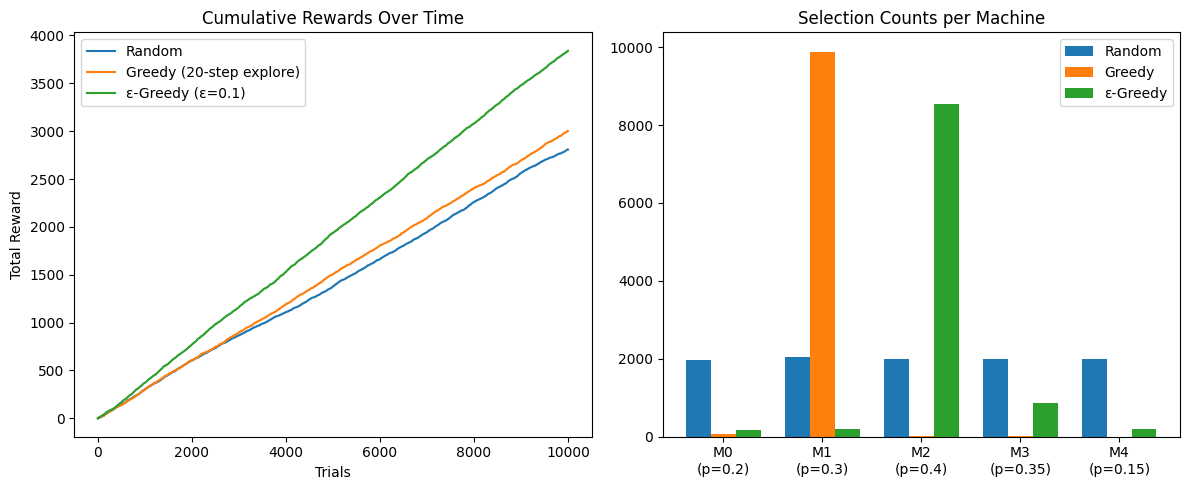

In [ ]:
plt.figure(figsize=(12, 5))

# 그래프 1: 누적 보상 추이
plt.subplot(1, 2, 1)
plt.plot(random_history, label='Random')
plt.plot(greedy_history, label='Greedy (20-step explore)')
plt.plot(egreedy_history, label='ε-Greedy (ε=0.1)')
plt.title('Cumulative Rewards Over Time')
plt.xlabel('Trials')
plt.ylabel('Total Reward')
plt.legend()

# 그래프 2: 머신별 선택 횟수 비교
plt.subplot(1, 2, 2)
bar_width = 0.25
index = np.arange(n_arms)
plt.bar(index - bar_width, random_counts, bar_width, label='Random')
plt.bar(index, greedy_counts, bar_width, label='Greedy')
plt.bar(index + bar_width, egreedy_counts, bar_width, label='ε-Greedy')
plt.title('Selection Counts per Machine')
plt.xticks(index, [f'M{i}\n(p={true_probs[i]})' for i in range(n_arms)])
plt.legend()

plt.tight_layout()
plt.show()

### ε값 변화 실험(0.1 vs 0.01)

In [ ]:
n_arms = 5
n_trials = 100000
true_probs = [0.2, 0.3, 0.4, 0.35, 0.15]

In [ ]:
egreedy_counts_01, egreedy_total_01, egreedy_history_01 = epsilon_greedy_bandit(n_trials, 0.1)

egreedy_counts_001, egreedy_total_001, egreedy_history_001 = epsilon_greedy_bandit(n_trials, 0.01)

print(f"ε=0.1 결과 - 총 보상: {egreedy_total_01}, 선택 횟수: {egreedy_counts_01}")
print(f"ε=0.01 결과 - 총 보상: {egreedy_total_001}, 선택 횟수: {egreedy_counts_001}")

ε=0.1 결과 - 총 보상: 38839, 선택 횟수: [ 2128.  2024. 91887.  2010.  1951.]
ε=0.01 결과 - 총 보상: 39757, 선택 횟수: [  222.  1676. 97716.   181.   205.]


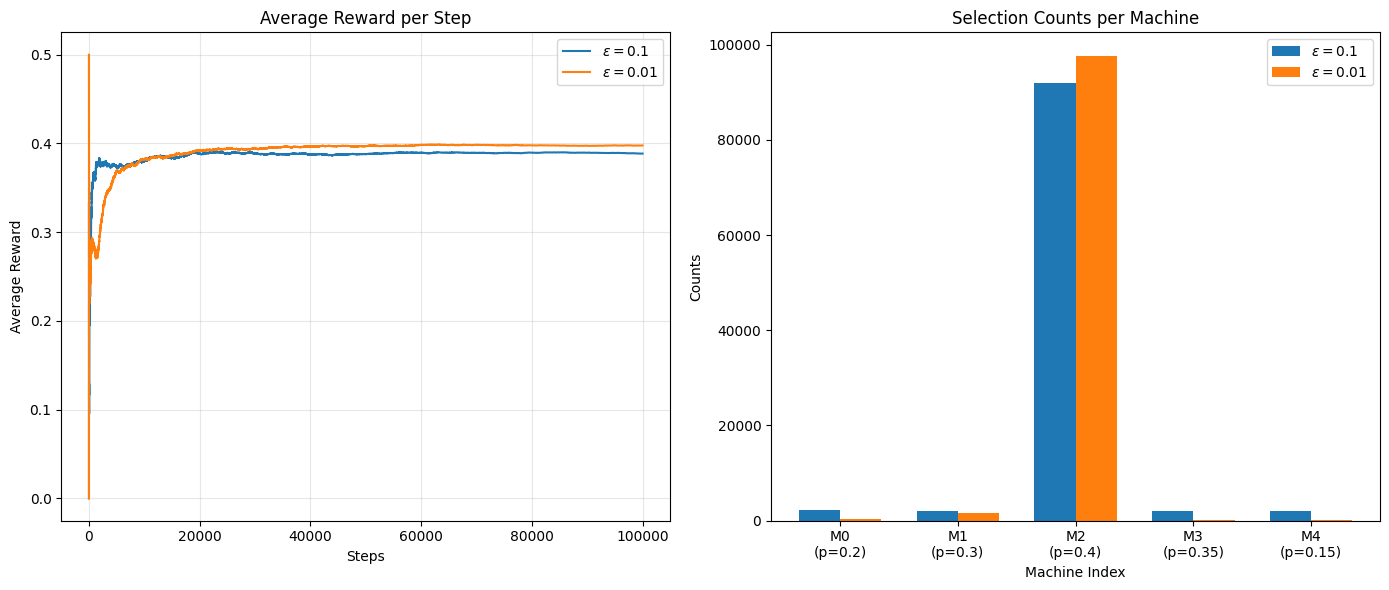

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 시점별 평균 보상 계산 (누적 보상 / 현재 시점)
steps = np.arange(1, n_trials + 1)
avg_reward_01 = np.array(egreedy_history_01) / steps
avg_reward_001 = np.array(egreedy_history_001) / steps

plt.figure(figsize=(14, 6))

# --- 그래프 1: 평균 보상 추이 ---
plt.subplot(1, 2, 1)
plt.plot(avg_reward_01, label=r'$\epsilon = 0.1$')
plt.plot(avg_reward_001, label=r'$\epsilon = 0.01$')

plt.title('Average Reward per Step')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend()
plt.grid(True, alpha=0.3)

# --- 그래프 2: 머신별 선택 횟수 ---
plt.subplot(1, 2, 2)
index = np.arange(n_arms)
bar_width = 0.35

plt.bar(index - bar_width/2, egreedy_counts_01, bar_width, label=r'$\epsilon = 0.1$')
plt.bar(index + bar_width/2, egreedy_counts_001, bar_width, label=r'$\epsilon = 0.01$')

plt.title('Selection Counts per Machine')
plt.xticks(index, [f'M{i}\n(p={true_probs[i]})' for i in range(n_arms)])
plt.xlabel('Machine Index')
plt.ylabel('Counts')
plt.legend()

plt.tight_layout()
plt.show()